# Posthoc Analysis of Best Optuna Trial

This notebook analyzes the best hierarchical VAE (h_vae) checkpoint found by Optuna.

Goals:
1. Estimate the contribution of each antenna to the h_vae encoding using occlusion sensitivity.
2. Estimate the contribution of each Gaussian mixture branch using posterior responsibilities and reconstruction fidelity.

In [1]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scienceplots  # noqa: F401
import torch
import torch.nn.functional as func
from sklearn.manifold import TSNE
from sklearn.metrics import confusion_matrix

from charl_tre import dataset, util
from charl_tre.models import hierarchical
from charl_tre.models.classifier import Classifier
from charl_tre.settings import Settings

plt.style.use(["science", "no-latex", "bright"])
plt.rcParams.update({"figure.dpi": 300, "svg.fonttype": "none"})

settings = Settings()

OUT_DIR = Path("../out")
STUDY_DIR = OUT_DIR / settings.study_name
PLOTS_DIR = STUDY_DIR / "plots"
DATASET_DIR = Path("../") / settings.dataset_path
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
EPS = 1e-8

PLOTS_DIR.mkdir(exist_ok=True)

/mnt/servicesdata/lcotti/charl_tre/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
best_trial_path = util.get_best_model_path(STUDY_DIR)

with (best_trial_path / "results.json").open("r") as f:
    trial_info = json.load(f)

params = trial_info["params"]

util.init_rng(settings.seed)

h_vae = hierarchical.Fusion(
    window_size=settings.vae_window_size,
    n_subcarriers=settings.n_subcarriers,
    n_dirichlet_components=int(params["n_components"]),
    n_mixtures=int(params["n_mixtures"]),
    n_fusion_layers=int(params["n_fusion_layers"]),
    fusion_dropout=float(params["fusion_dropout"]),
    n_antennas=settings.n_antennas,
)

state_dict = torch.load(best_trial_path / "h_vae.pt", map_location=DEVICE)
h_vae.load_state_dict(state_dict)
h_vae.to(DEVICE)
h_vae.eval()

classifier_model = Classifier(
    antennas=[h_vae],
    n_components=params["n_components"] * params["n_mixtures"],
    n_activities=settings.n_activities,
    sample_window_size=settings.vae_window_size,
    overlap_size=settings.overlap_size,
    n_layers=1,
    dropout=0,
).to(DEVICE)
classifier_model_weights = torch.load(best_trial_path / "classifier.pt", weights_only=True)
classifier_model.load_state_dict(classifier_model_weights, strict=True)

print(f"Best trial path: {best_trial_path}")
print(f"Objective score: {trial_info['objective_score']:.4f}")
print(f"n_components={params['n_components']}, n_mixtures={params['n_mixtures']}, batch_size={params['batch_size']}")

Best trial path: ../out/hvae_vw75_cw450/trial_77
Objective score: 0.9603
n_components=32, n_mixtures=4, batch_size=64


In [3]:
# Datasets for h_vae latent-space analyses (window=vae_window_size)
train_ds_vae, val_ds_vae, test_ds_vae = dataset.load(
    dataset_path=DATASET_DIR,
    window_size=settings.vae_window_size,
    n_activities=settings.n_activities,
    stride=settings.stride,
)

test_dl_vae = util.make_dl(
    test_ds_vae,
    batch_size=int(params["batch_size"]),
    shuffle=False,
    num_workers=0,
    seed=settings.seed,
)
full_dl_vae = util.make_dl(
    torch.utils.data.ConcatDataset([train_ds_vae, val_ds_vae, test_ds_vae]),
    batch_size=int(params["batch_size"]),
    shuffle=False,
    num_workers=0,
    seed=settings.seed,
)

# Dataset for classifier evaluation (window=classifier_window_size)
_, _, test_ds_cls = dataset.load(
    dataset_path=DATASET_DIR,
    window_size=settings.classifier_window_size,
    n_activities=settings.n_activities,
    stride=settings.stride,
)

test_dl_cls = util.make_dl(
    test_ds_cls,
    batch_size=int(params["batch_size"]),
    shuffle=False,
    num_workers=0,
    seed=settings.seed,
)

X_list, Y_list = [], []
for x, y in test_dl_vae:
    X_list.append(x)
    Y_list.append(y)

X = torch.cat(X_list, dim=0).float().to(DEVICE)
Y = torch.cat(Y_list, dim=0).to(DEVICE)

x_example = X[0]
print(f"Loaded {X.shape[0]} VAE windows for posthoc analysis.")
print(f"Input shape: {x_example.shape}")
print(f"Input dtype on device: {x_example.dtype}")
print(f"Classifier test windows: {len(test_ds_cls)}")

Loaded 1128 VAE windows for posthoc analysis.
Input shape: torch.Size([4, 75, 256])
Input dtype on device: torch.float32
Classifier test windows: 948


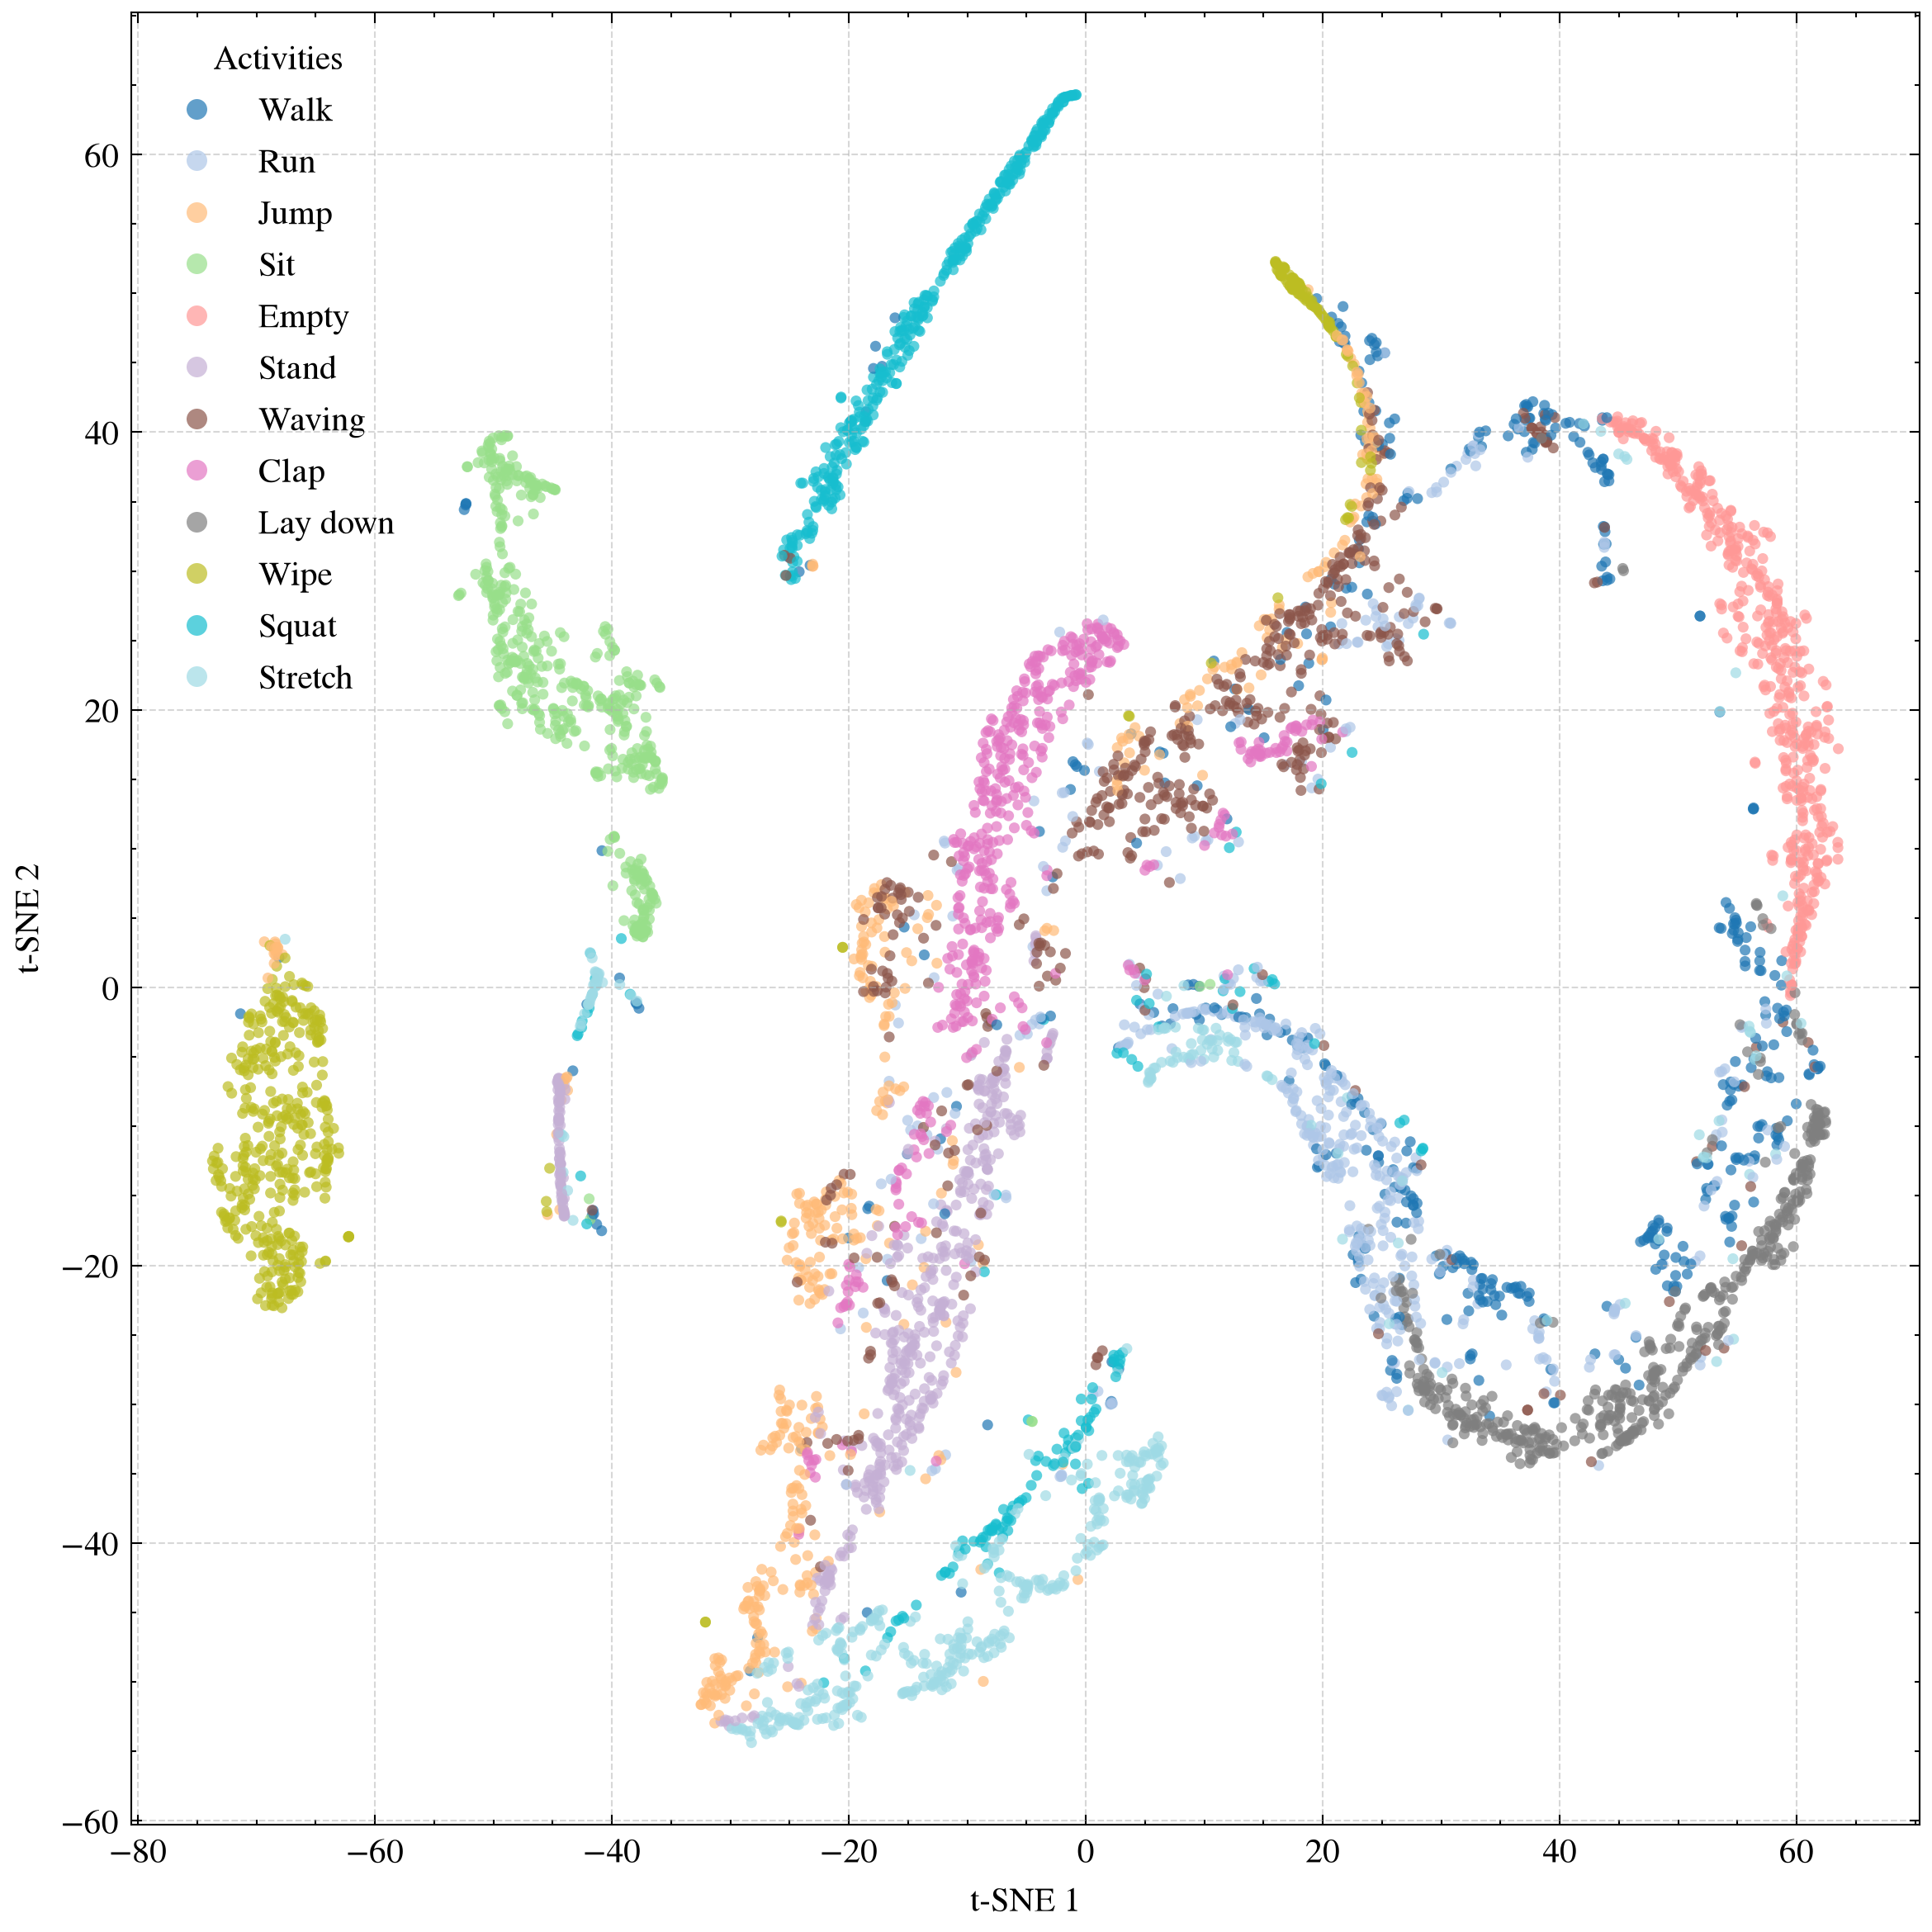

In [4]:
@torch.no_grad()
def plot_tsne(
    model: hierarchical.Fusion,
    dataloader: torch.utils.data.DataLoader,
    activities: list[str],
    seed: int,
    out_dir: Path,
    device: torch.device,
) -> None:
    """Plot t-SNE projection of mixture-aware Dirichlet latents."""
    latents_list: list[np.ndarray] = []
    labels_list: list[np.ndarray] = []

    for x, y in dataloader:
        _, mix_logits, alpha, *_ = model(x.float().to(device))

        # alpha: (B, M, C), mix_probs: (B, M)
        mix_probs = func.softmax(mix_logits, dim=-1)

        # Mixture-aware sample embedding: flatten weighted alpha and mixture probs.
        # Shape becomes (B, M*C + M), i.e. one latent vector per sample.
        weighted_alpha = alpha * mix_probs.unsqueeze(-1)
        latent_vec = torch.cat(
            [
                weighted_alpha.reshape(weighted_alpha.shape[0], -1),
                mix_probs,
            ],
            dim=-1,
        )

        latents_list.append(latent_vec.cpu().numpy())
        labels_list.append(y.numpy())

    latents = np.concatenate(latents_list, axis=0)
    labels = np.concatenate(labels_list, axis=0)

    tsne = TSNE(
        n_components=2,
        random_state=seed,
        perplexity=50,
    )
    emb = tsne.fit_transform(latents)

    plt.figure(figsize=(8, 8))
    scatter = plt.scatter(
        emb[:, 0],
        emb[:, 1],
        c=labels,
        cmap="tab20",
        alpha=0.7,
        s=10,
        linewidths=0,
        vmin=0,
        vmax=len(activities) - 1,
    )

    plt.xlabel("t-SNE 1")
    plt.ylabel("t-SNE 2")
    plt.grid(True, linestyle="--", alpha=0.5)

    handles, _ = scatter.legend_elements(prop="colors", num=len(activities))
    plt.legend(
        handles,
        activities,
        title="Activities",
    )

    plt.tight_layout()
    plt.savefig(out_dir / "tsne.pdf", bbox_inches="tight")
    plt.show()


plot_tsne(h_vae, full_dl_vae, settings.activities, settings.seed, PLOTS_DIR, DEVICE)

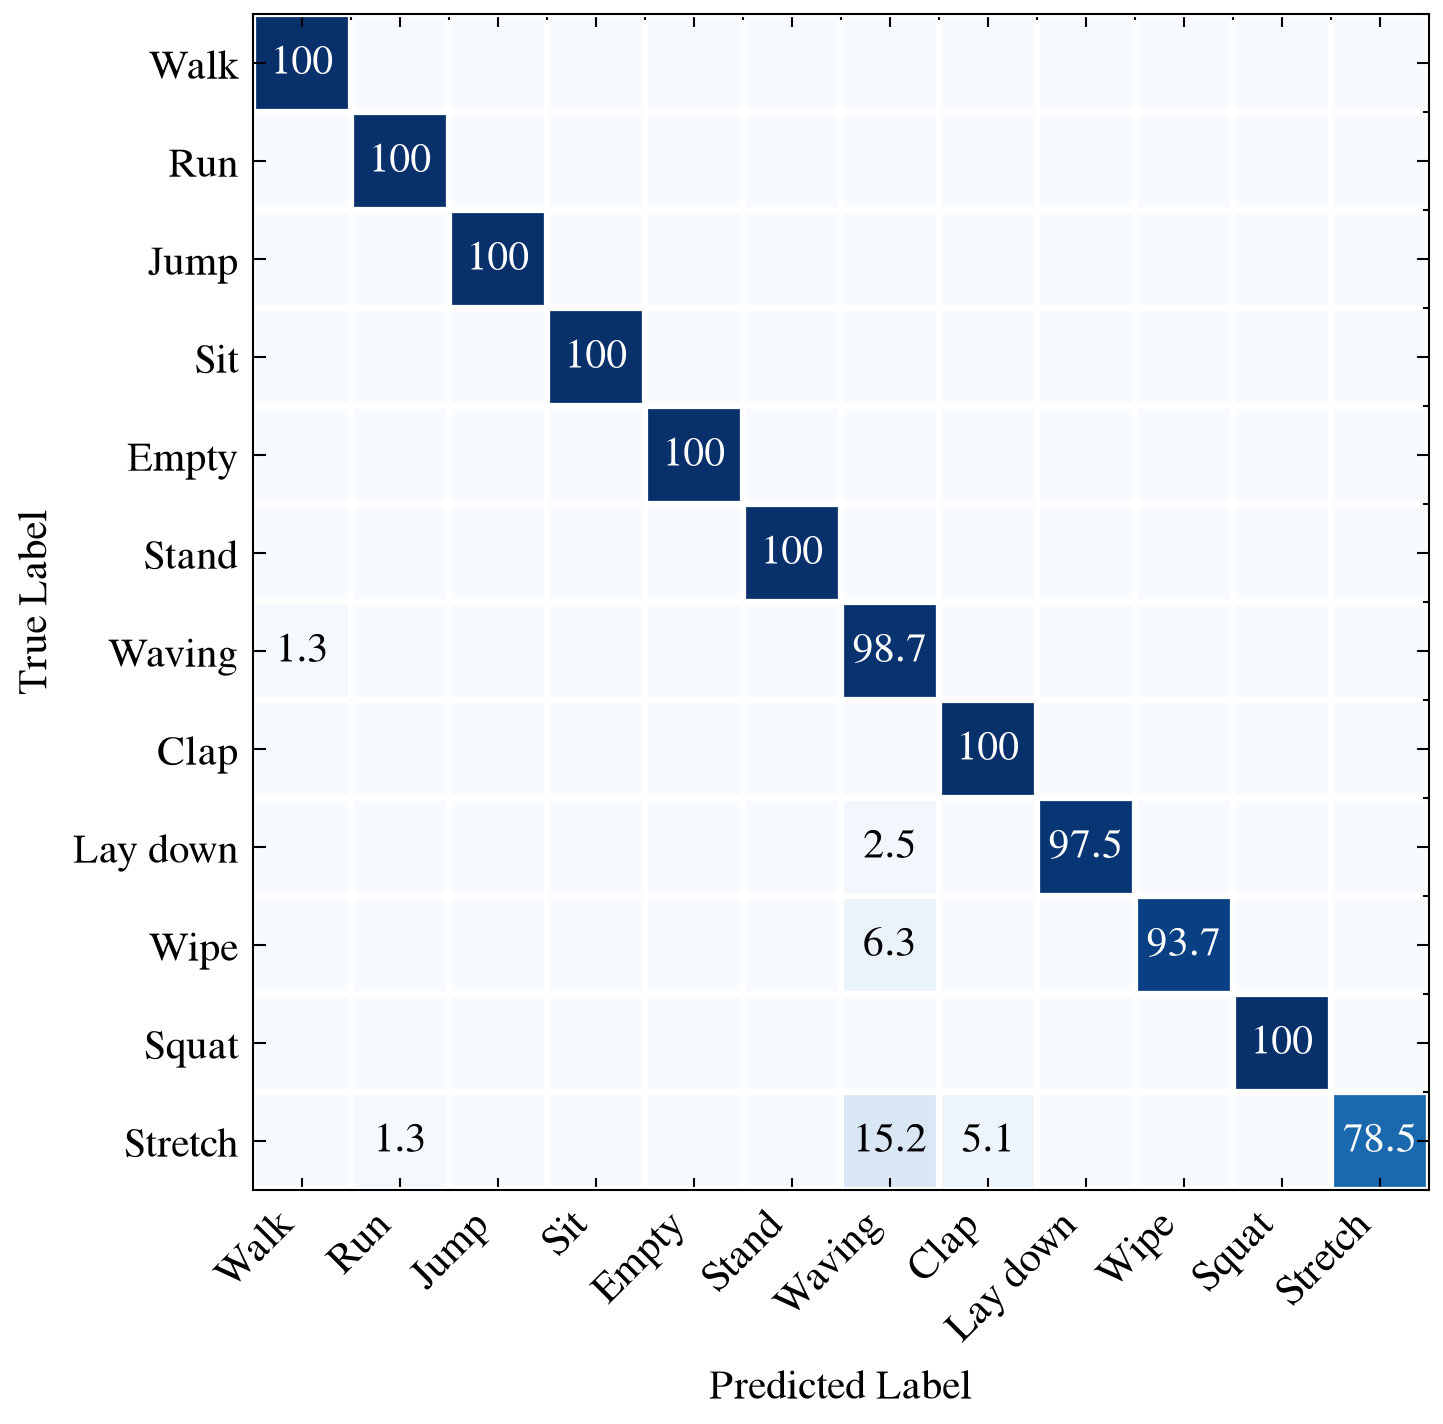

In [5]:
def plot_confusion_matrix(
    model: torch.nn.Module,
    dataloader: torch.utils.data.DataLoader,
    activities: list[str],
    name: str,
    device: torch.device,
    figsize: tuple[int, int] = (5, 5),
) -> None:
    """Plot a row-normalized confusion matrix for a classifier."""
    model.eval()

    y_preds: list[np.ndarray] = []
    y_trues: list[np.ndarray] = []

    for x, y in dataloader:
        with torch.no_grad():
            logits = model(x.to(device, dtype=torch.float32))
            y_preds.append(logits.cpu().numpy())
            y_trues.append(y.numpy())

    cm = confusion_matrix(
        np.concatenate(y_trues),
        np.concatenate(y_preds).argmax(axis=1),
    )

    plt.figure(figsize=figsize)
    matrix_perc = cm.astype("float") / (cm.sum(axis=1)[:, np.newaxis] + 1e-12)
    plt.imshow(matrix_perc, cmap="Blues")

    thresh = matrix_perc.max() / 2
    for i in range(len(activities)):
        for j in range(len(activities)):
            if cm[i, j] == 0:
                continue

            color = "white" if matrix_perc[i, j] > thresh else "black"
            text = f"{matrix_perc[i, j] * 100:.1f}".rstrip("0").rstrip(".")
            plt.text(j, i, text, ha="center", va="center", color=color)

    plt.ylabel("True Label")
    plt.xlabel("Predicted Label")
    plt.xticks(rotation=45, ha="right", ticks=np.arange(len(activities)), labels=activities)
    plt.yticks(rotation=0, ticks=np.arange(len(activities)), labels=activities)

    ax = plt.gca()
    ax.set_xticks(np.arange(-0.5, len(activities)), minor=True)
    ax.set_yticks(np.arange(-0.5, len(activities)), minor=True)
    ax.grid(which="minor", color="white", linewidth=1.5)
    ax.tick_params(which="minor", bottom=False, left=False)

    plt.tight_layout()
    plt.savefig(PLOTS_DIR / name, bbox_inches="tight")
    plt.show()


plot_confusion_matrix(classifier_model, test_dl_cls, settings.activities, "confusion_matrix.pdf", DEVICE)

In [6]:
def js_divergence(p: torch.Tensor, q: torch.Tensor, eps: float = 1e-8) -> torch.Tensor:
    """Compute the Jensen-Shannon divergence between two probability distributions.

    Arguments:
        p (torch.Tensor): A tensor of shape (B, N) representing the first probability distribution.
        q (torch.Tensor): A tensor of shape (B, N) representing the second probability distribution.
        eps (float): A small value to avoid division by zero and log of zero.

    Returns:
        torch.Tensor: A tensor of shape (B,) containing
            the Jensen-Shannon divergence for each pair of distributions.

    """
    p = torch.clamp(p, min=eps)
    q = torch.clamp(q, min=eps)
    p = p / p.sum(dim=-1, keepdim=True)
    q = q / q.sum(dim=-1, keepdim=True)
    m = 0.5 * (p + q)
    kl_pm = (p * (torch.log(p) - torch.log(m))).sum(dim=-1)
    kl_qm = (q * (torch.log(q) - torch.log(m))).sum(dim=-1)
    return 0.5 * (kl_pm + kl_qm)


def expected_recon_mse(
    recon: torch.Tensor,
    x_true: torch.Tensor,
    mix_probs: torch.Tensor,
) -> tuple[torch.Tensor, torch.Tensor]:
    """Compute the expected reconstruction MSE for a mixture of Gaussians.

    Arguments:
        recon (torch.Tensor): A tensor of shape (B, M, A, W, S)
            representing the reconstructed signals from the mixture model.
        x_true (torch.Tensor): A tensor of shape (B, A, W, S) representing the true signals.
        mix_probs (torch.Tensor): A tensor of shape (B, M) representing the mixture probabilities for each component.

    Returns:
        tuple[torch.Tensor, torch.Tensor]: A tuple containing:
            - weighted (torch.Tensor): A tensor of shape (B,) containing
                the expected reconstruction MSE for each sample in the batch.
            - per_mix_mse (torch.Tensor): A tensor of shape (B, M) containing
                the reconstruction MSE for each mixture component and each sample in the batch.

    """
    per_mix_mse = ((recon - x_true[:, None]) ** 2).mean(dim=(2, 3, 4))
    weighted = (mix_probs * per_mix_mse).sum(dim=-1)
    return weighted, per_mix_mse

In [7]:
with torch.no_grad():
    recon_ref, mix_logits_ref, alpha_ref, *_ = h_vae(X)
    mix_probs_ref = func.softmax(mix_logits_ref, dim=-1)
    exp_mse_ref, per_mix_mse_ref = expected_recon_mse(recon_ref, X, mix_probs_ref)

antenna_rows = []
for antenna_idx in range(settings.n_antennas):
    x_occ = X.clone()
    x_occ[:, antenna_idx] = 0.0

    with torch.no_grad():
        recon_occ, mix_logits_occ, alpha_occ, *_ = h_vae(x_occ)
        mix_probs_occ = func.softmax(mix_logits_occ, dim=-1)
        exp_mse_occ, _ = expected_recon_mse(recon_occ, x_occ, mix_probs_occ)

    antenna_rows.append(
        {
            "antenna": f"Antenna {antenna_idx + 1}",
            "delta_expected_mse": float((exp_mse_occ - exp_mse_ref).mean().cpu()),
            "mix_js_divergence": float(js_divergence(mix_probs_ref, mix_probs_occ).mean().cpu()),
            "delta_alpha_l1": float((alpha_occ - alpha_ref).abs().mean().cpu()),
        },
    )

antenna_df = pd.DataFrame(antenna_rows)
antenna_df

,antenna,delta_expected_mse,mix_js_divergence,delta_alpha_l1
0,Antenna 1,0.063501,0.074677,25.292801
1,Antenna 2,0.030876,0.084685,20.156315
2,Antenna 3,0.045049,0.315486,18.818377
3,Antenna 4,0.011693,0.521544,53.395969


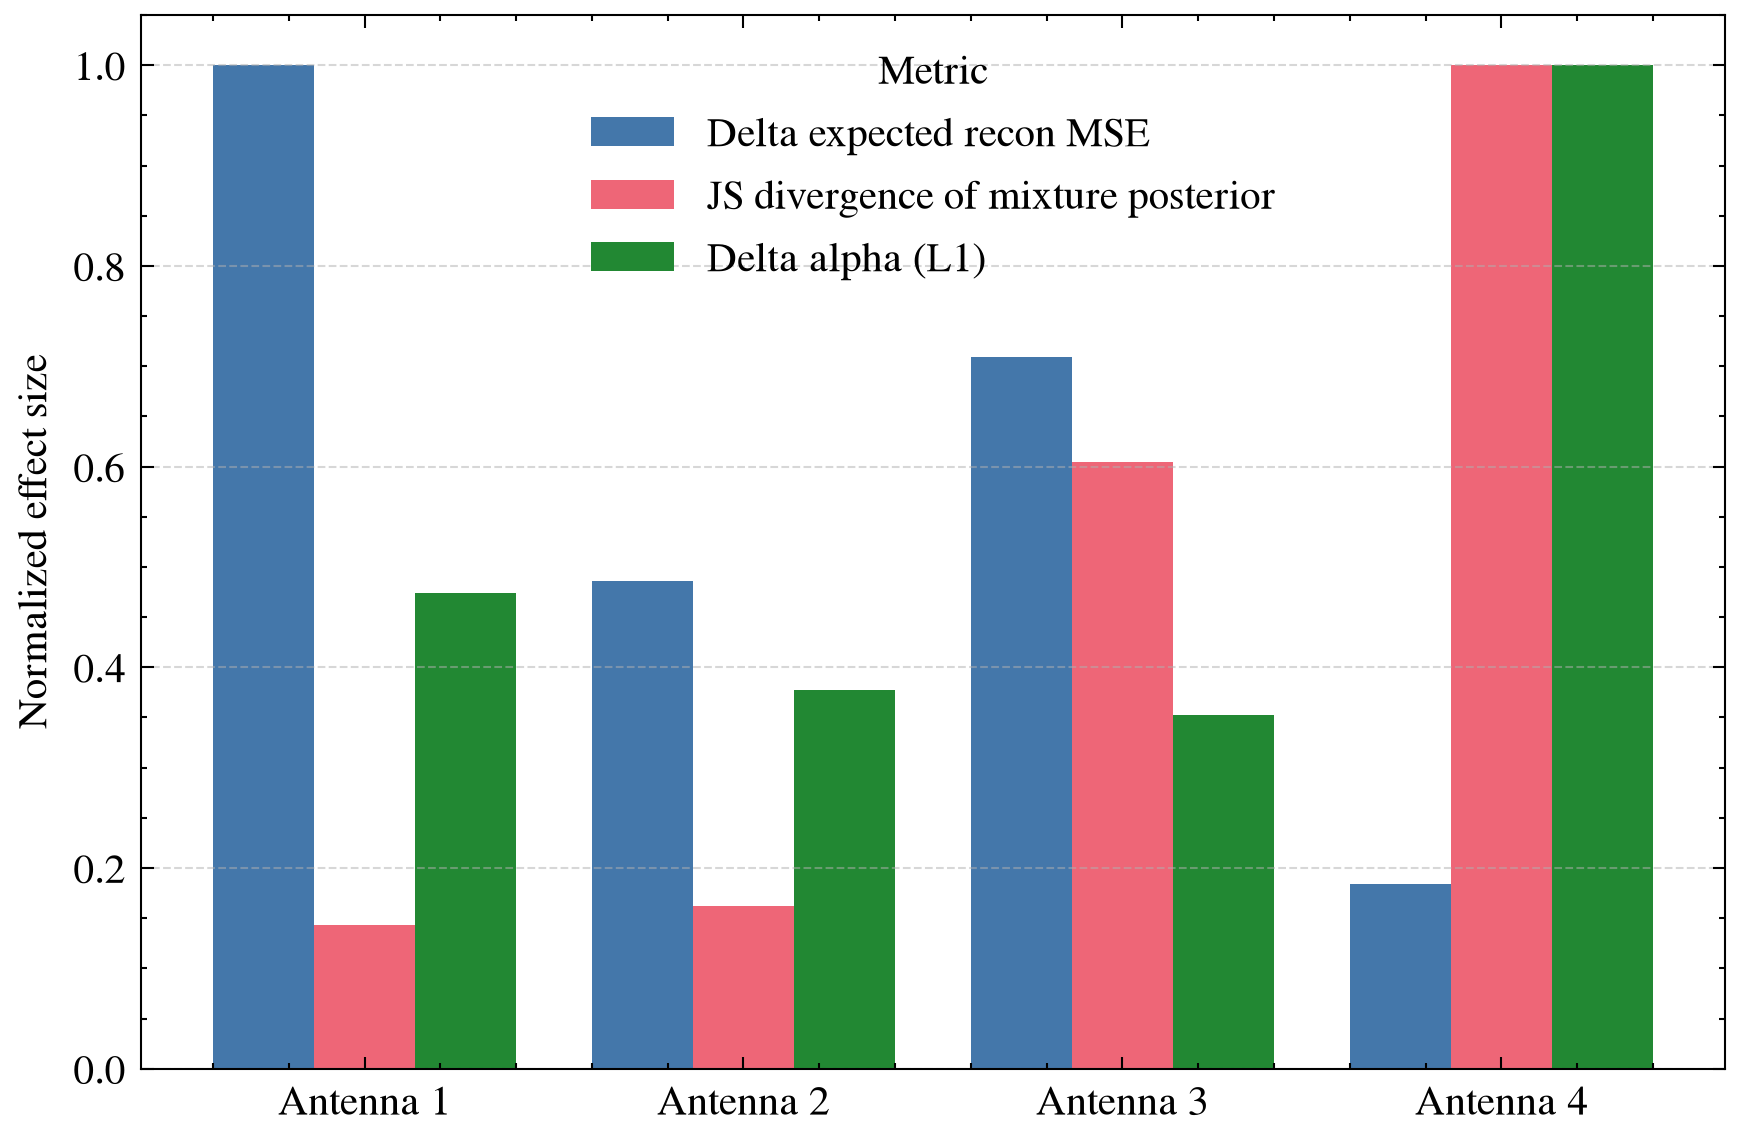

In [8]:
plot_df = antenna_df.copy()
for col in ["delta_expected_mse", "mix_js_divergence", "delta_alpha_l1"]:
    denom = plot_df[col].abs().max()
    plot_df[f"{col}_norm"] = plot_df[col] / (denom + 1e-12)

plot_long = plot_df.melt(
    id_vars=["antenna"],
    value_vars=[
        "delta_expected_mse_norm",
        "mix_js_divergence_norm",
        "delta_alpha_l1_norm",
    ],
    var_name="metric",
    value_name="normalized_score",
)

metric_names = {
    "delta_expected_mse_norm": "Delta expected recon MSE",
    "mix_js_divergence_norm": "JS divergence of mixture posterior",
    "delta_alpha_l1_norm": "Delta alpha (L1)",
}
plot_long["metric"] = plot_long["metric"].map(metric_names)

antennas = list(plot_long["antenna"].unique())
metrics = list(plot_long["metric"].unique())
x = np.arange(len(antennas))
width = 0.8 / len(metrics)

plt.figure(figsize=(6, 4))
for i, metric in enumerate(metrics):
    vals = plot_long[plot_long["metric"] == metric]["normalized_score"].to_numpy()
    plt.bar(x + (i - len(metrics) / 2 + 0.5) * width, vals, width=width, label=metric)

plt.xticks(x, antennas)
plt.ylabel("Normalized effect size")
plt.xlabel("")
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.legend(title="Metric")
plt.tight_layout()
plt.show()

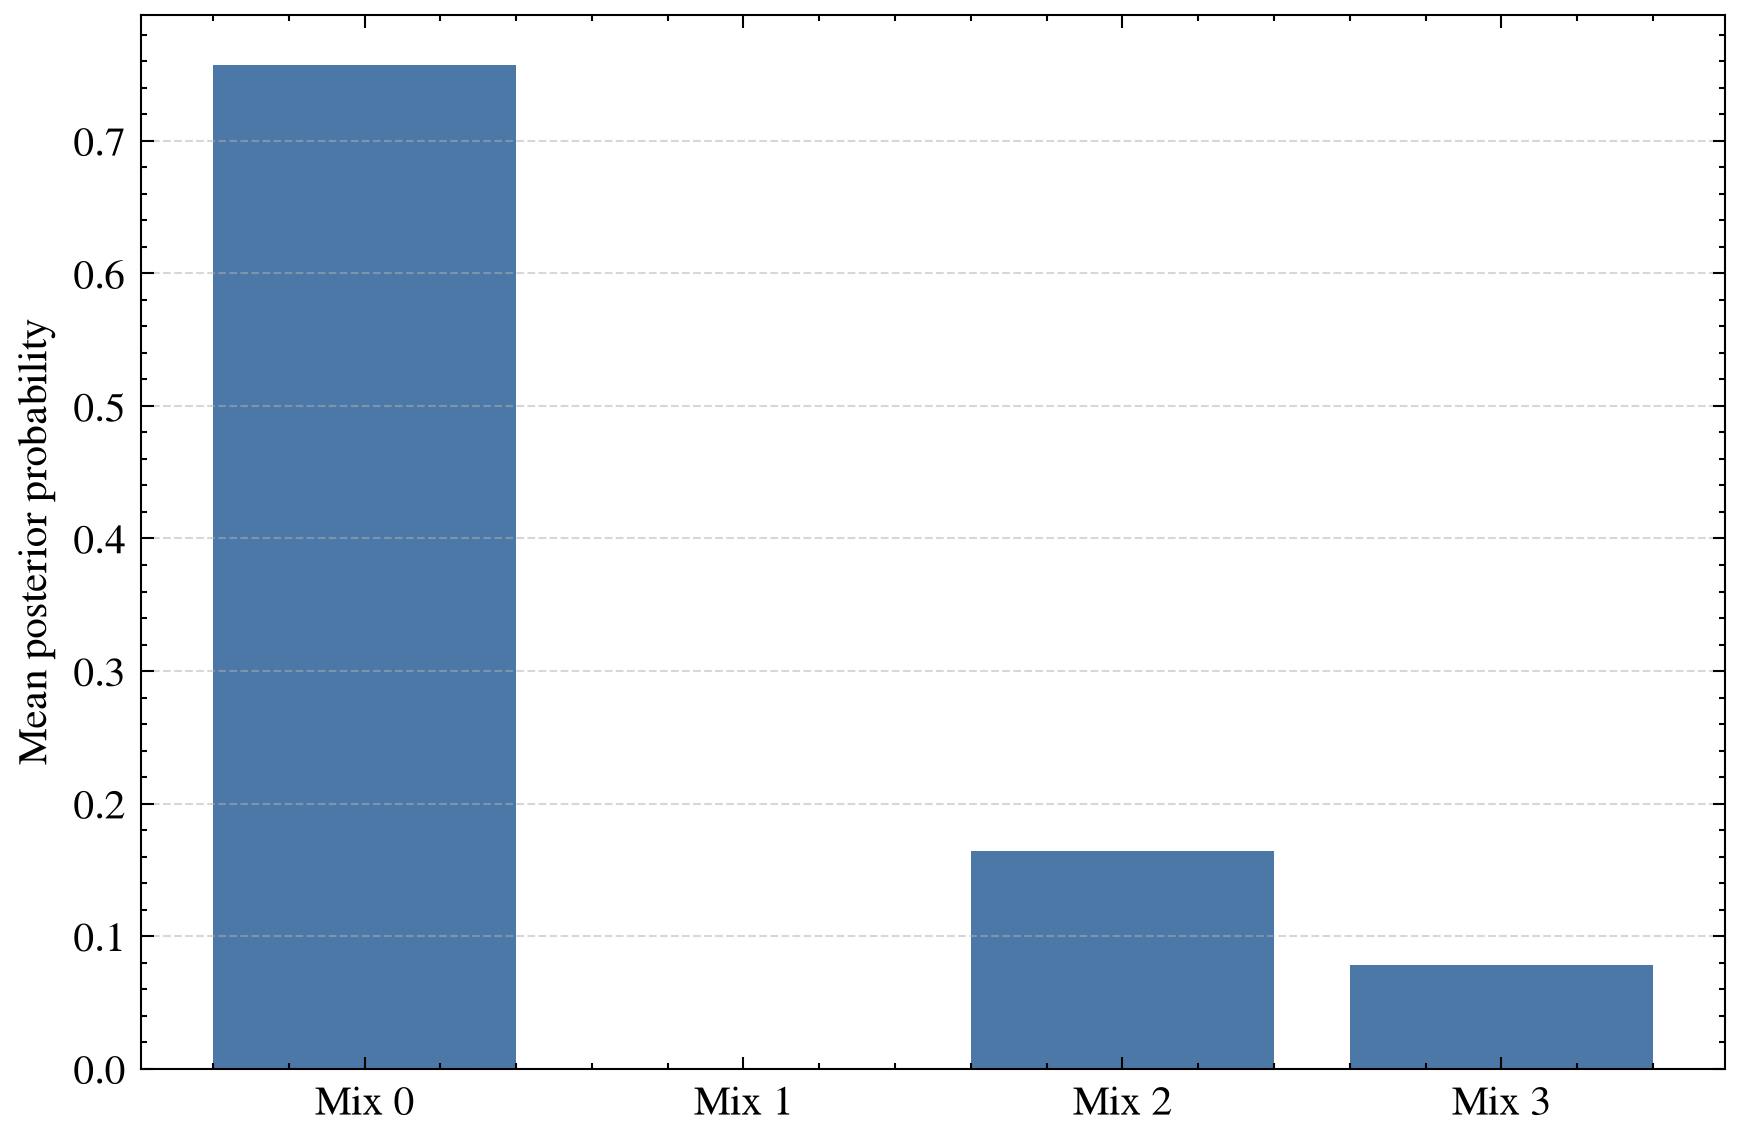

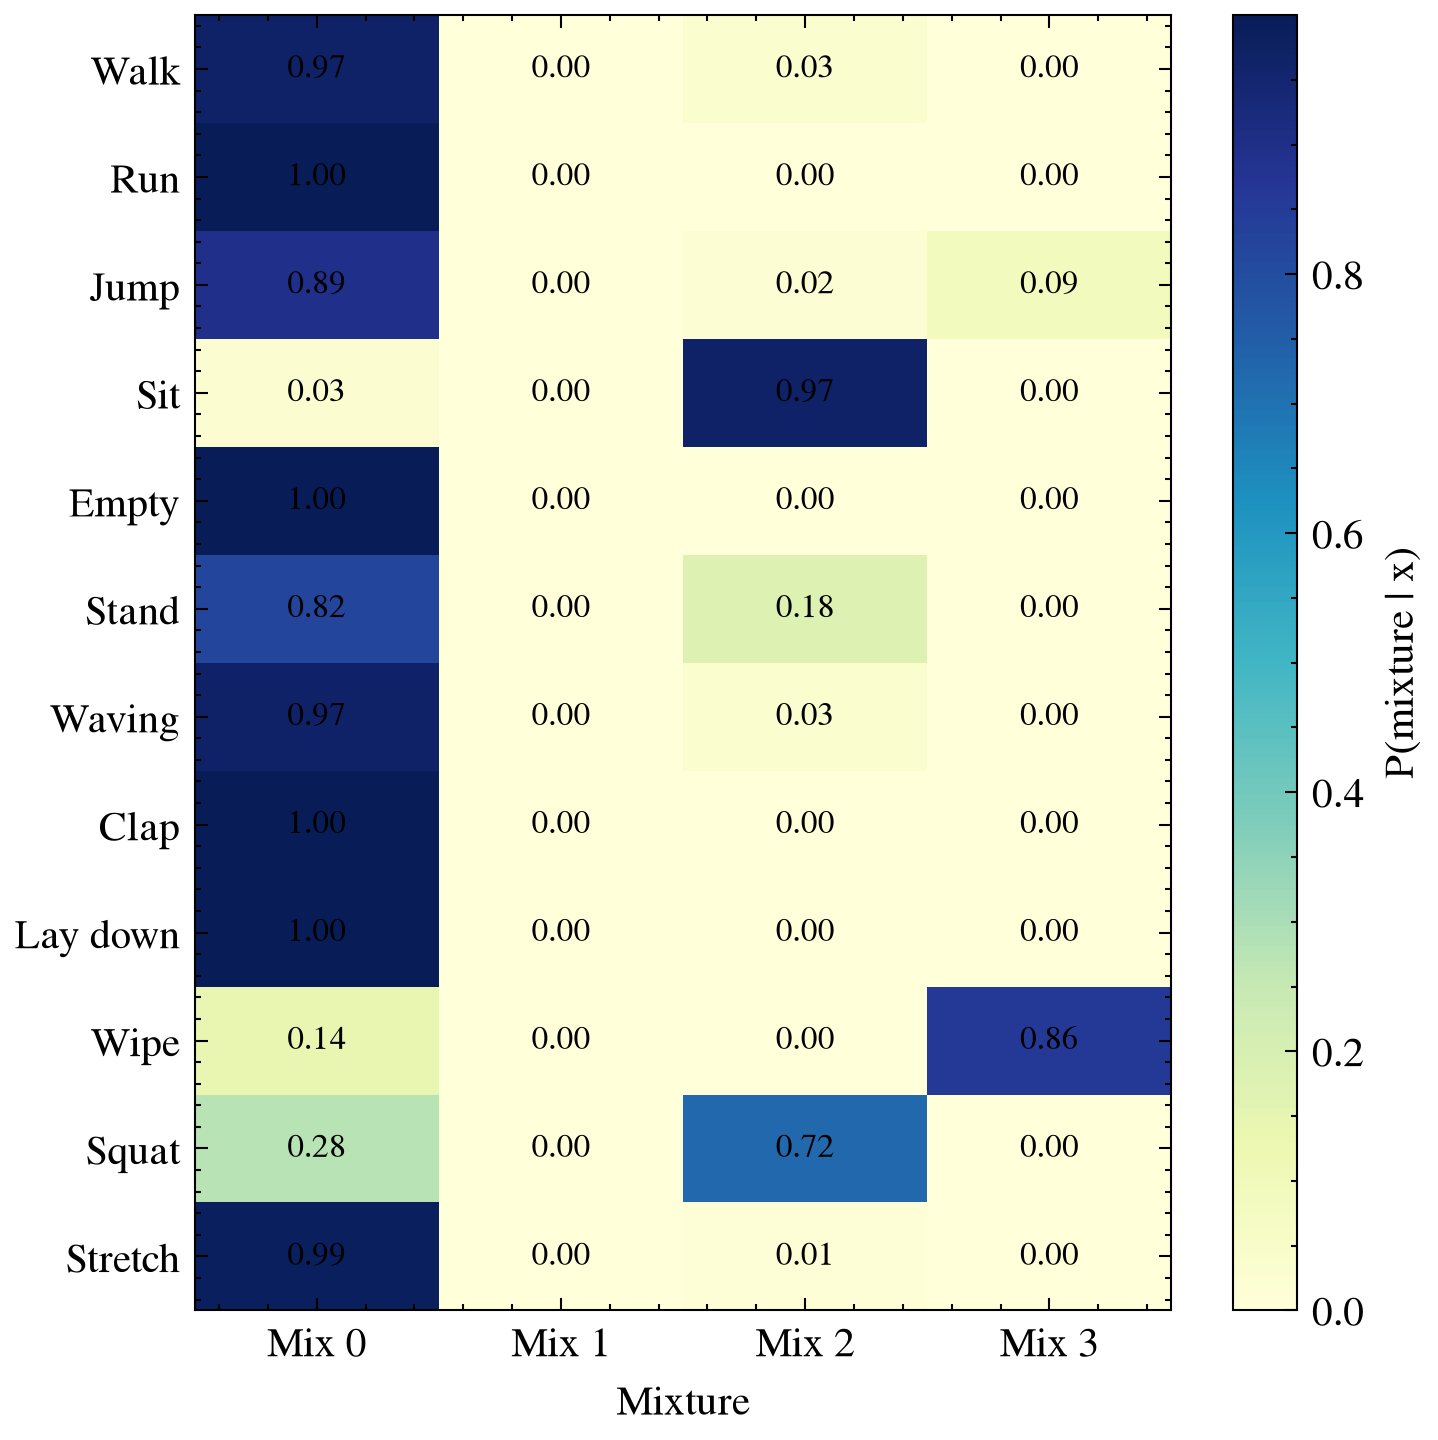

In [9]:
# Mixture-level contribution metrics from the reference forward pass.
mix_usage = mix_probs_ref.mean(dim=0).cpu().numpy()
hard_assign_rate = mix_probs_ref.argmax(dim=-1).bincount(minlength=mix_probs_ref.shape[1]).float()
hard_assign_rate = (hard_assign_rate / hard_assign_rate.sum()).cpu().numpy()
mean_forced_mse = per_mix_mse_ref.mean(dim=0).cpu().numpy()
weighted_mse_share = (mix_probs_ref * per_mix_mse_ref).mean(dim=0).cpu().numpy()
weighted_fidelity = (mix_probs_ref / (per_mix_mse_ref + EPS)).mean(dim=0).cpu().numpy()

mix_df = pd.DataFrame(
    {
        "mixture": [f"Mix {i}" for i in range(mix_probs_ref.shape[1])],
        "mean_posterior_prob": mix_usage,
        "hard_assignment_rate": hard_assign_rate,
        "mean_forced_mse": mean_forced_mse,
        "weighted_mse_share": weighted_mse_share,
        "weighted_fidelity": weighted_fidelity,
    },
)

# Activity-conditioned posterior usage of each mixture.
activity_names = settings.activities[: settings.n_activities]
activity_ids = Y.cpu().numpy()
all_mixtures = [f"Mix {i}" for i in range(mix_probs_ref.shape[1])]

activity_mix = []
for activity_idx, activity_name in enumerate(activity_names):
    idx = np.where(activity_ids == activity_idx)[0]
    probs_mean = mix_probs_ref[idx].mean(dim=0).cpu().numpy() if len(idx) > 0 else np.zeros(len(all_mixtures))
    for mix_idx, prob in enumerate(probs_mean):
        activity_mix.append({
            "activity": activity_name,
            "mixture": f"Mix {mix_idx}",
            "mean_posterior_prob": float(prob),
        })

activity_mix_df = pd.DataFrame(activity_mix)
pivot_activity_mix = activity_mix_df.pivot_table(
    index="activity",
    columns="mixture",
    values="mean_posterior_prob",
).reindex(index=activity_names, columns=all_mixtures)


# --- Global mixture usage bar chart ---
plt.figure(figsize=(6, 4))
plt.bar(mix_df["mixture"], mix_df["mean_posterior_prob"], color="#4C78A8")
plt.ylabel("Mean posterior probability")
plt.xlabel("")
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

# --- Activity per mixture heatmap ---
plt.figure(figsize=(5, 5))
heatmap_data = pivot_activity_mix.to_numpy()
im = plt.imshow(heatmap_data, cmap="YlGnBu", aspect="auto", vmin=0, vmax=heatmap_data.max())
plt.xticks(np.arange(len(all_mixtures)))
plt.yticks(np.arange(len(activity_names)))
plt.xticks(np.arange(len(all_mixtures)), all_mixtures)
plt.yticks(np.arange(len(activity_names)), activity_names)

for row in range(heatmap_data.shape[0]):
    for col in range(heatmap_data.shape[1]):
        plt.text(col, row, f"{heatmap_data[row, col]:.2f}", ha="center", va="center", fontsize=8)

plt.colorbar(im, label="P(mixture | x)")
plt.xlabel("Mixture")
plt.ylabel("")
plt.tight_layout()
plt.show()